NCO - Numerically Controlled Oscillator

$$ f_{out} = \frac{f_s \Delta \Phi}{2^M} $$

where $\Delta \Phi$ is the tuning word (phase increment per clock), $M$ is accumulator bit width, $f_s$ is clock frequency. Frequency resolution is $f_s / 2^M$. 

We will use 32 bit resolution because 16 would yield a resolution of 762 Hz vs 0.012 Hz with 16 bit.

We want a phase locked 38 kHz for shift and 19 kHz for pilot reference signal. 

- Option 1: We will drive the phase accumulator at 38 kHz and divide the frequency to 19 kHz later. Both drive a cordic.

- Option 2: Generate cos(19 kHz) and sin(19kHz) and get $\sin(38 kHz) = 2 * \sin(19 kHz) * \cos(19 kHz)$ (this might be the easier option)




In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [8]:
# Parameters

N_BITS = 32
CLOCK_FREQ = 50_000_000
OUT_FREQ = 19_000 # will get doubled as well
N_ITER = 20

In [15]:
def build_cordic_table(n_iter: int) -> np.ndarray:
    """Precomputed angle table: alpha_i = arctan(2^-i)"""
    return np.array([np.arctan(2.0**-i) for i in range(n_iter)])

def cordic_gain(n_iter: int) -> float:
    """Total CORDIC vector gain K = prod(cos(alpha_i))"""
    return float(np.prod(np.cos(np.arctan(2.0**-np.arange(n_iter)))))

# Precompute once
ALPHA = build_cordic_table(N_ITER)
K     = cordic_gain(N_ITER)

def cordic_rotate(theta: float) -> tuple[float, float]:
    """
    CORDIC rotation mode: accepts any angle, handles range reduction
    and quadrant correction internally.
    Returns (cos(theta), sin(theta)).
    """
    # ── Range reduction: fold into (-pi/2, pi/2) ──────────────────────────
    theta = (theta + np.pi) % (2.0 * np.pi) - np.pi   # wrap to (-pi, pi)

    if theta > np.pi / 2:
        theta = np.pi - theta
        cos_sign, sin_sign = -1.0,  1.0   # Q2: cos flips
    elif theta < -np.pi / 2:
        theta = -np.pi - theta
        cos_sign, sin_sign = -1.0,  1.0   # Q3: cos flips, sin already negative
    else:
        cos_sign, sin_sign =  1.0,  1.0   # Q1/Q4: no flip

    # ── CORDIC iterations ─────────────────────────────────────────────────
    x, y, z = K, 0.0, theta

    for i, alpha in enumerate(ALPHA):
        d     = 1.0 if z >= 0 else -1.0
        shift = 2.0**-i
        x, y, z = (x - d * y * shift,
                   y + d * x * shift,
                   z - d * alpha)

    return cos_sign * x, sin_sign * y


class PhaseAccumulator:
    def __init__(self, n_bits: int, tuning_word: int):
        self.mask        = (1 << n_bits) - 1
        self.tuning_word = tuning_word & self.mask
        self.phase       = 0

    def tick(self) -> int:
        """Advance one clock cycle, return current phase value."""
        val        = self.phase
        self.phase = (self.phase + self.tuning_word) & self.mask
        return val

    def to_angle(self, phase: int) -> float:
        """Map integer phase [0, 2^N) → angle [0, 2*pi)"""
        return (phase / (self.mask + 1)) * 2.0 * np.pi

In [50]:
tuning_word = int(((OUT_FREQ * (1 << N_BITS)) / CLOCK_FREQ)+0.5) # = 1632088
actual_out_freq = (tuning_word * CLOCK_FREQ) / (1 << N_BITS) # = 19000.004977 Hz
print(f"Tuning word: {tuning_word}")
print(f"Actual output frequency: {actual_out_freq:.6f} Hz")

# plot phase accumulator output in x and fourier domains
acc = PhaseAccumulator(N_BITS, tuning_word)
n_samples = CLOCK_FREQ // OUT_FREQ * 4 # 4 periods worth of samples
print(n_samples, "samples per period")

phases = np.zeros(n_samples) # pre-allocate arrays for plotting
angles = np.zeros(n_samples)
increments = np.zeros(n_samples)

for i in range(n_samples):
    phases[i] = acc.tick()
    angles[i] = acc.to_angle(phases[i])
    increments[i] = i
    

cordic_out = np.array([cordic_rotate(theta) for theta in angles])
double_freq_out = 2 * cordic_out[:,0] * cordic_out[:,1] # sin(2 theta) = 2 sin(theta) cos(theta)

Tuning word: 1632088
Actual output frequency: 19000.004977 Hz
10524 samples per period


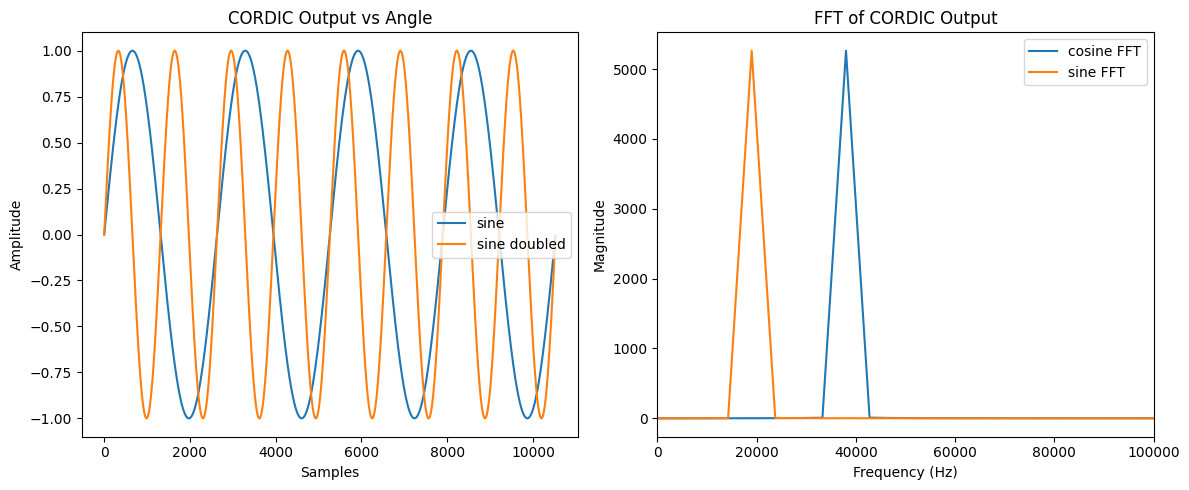

In [52]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(increments, cordic_out[:, 1], label='sine')
plt.plot(increments, double_freq_out, label='sine doubled')
plt.title('CORDIC Output vs Angle')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.subplot(1, 2, 2)
fft_cos = np.fft.fft(double_freq_out)
fft_sin = np.fft.fft(cordic_out[:, 1])
freqs = np.fft.fftfreq(n_samples, d=1/CLOCK_FREQ)
plt.plot(freqs[:n_samples//2], np.abs(fft_cos)[:n_samples//2], label='cosine FFT')
plt.plot(freqs[:n_samples//2], np.abs(fft_sin)[:n_samples//2], label='sine FFT')
plt.title('FFT of CORDIC Output')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 100_000) # focus on low frequencies
plt.legend()
plt.tight_layout()
plt.show()